In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/talhasar/genki4k/kaggle-genki4k/smile/file2125.jpg
/kaggle/input/datasets/talhasar/genki4k/kaggle-genki4k/smile/file1024.jpg
/kaggle/input/datasets/talhasar/genki4k/kaggle-genki4k/smile/file1578.jpg
/kaggle/input/datasets/talhasar/genki4k/kaggle-genki4k/smile/file0721.jpg
/kaggle/input/datasets/talhasar/genki4k/kaggle-genki4k/smile/file0961.jpg
/kaggle/input/datasets/talhasar/genki4k/kaggle-genki4k/smile/file0148.jpg
/kaggle/input/datasets/talhasar/genki4k/kaggle-genki4k/smile/file2045.jpg
/kaggle/input/datasets/talhasar/genki4k/kaggle-genki4k/smile/file0805.jpg
/kaggle/input/datasets/talhasar/genki4k/kaggle-genki4k/smile/file1816.jpg
/kaggle/input/datasets/talhasar/genki4k/kaggle-genki4k/smile/file1879.jpg
/kaggle/input/datasets/talhasar/genki4k/kaggle-genki4k/smile/file0682.jpg
/kaggle/input/datasets/talhasar/genki4k/kaggle-genki4k/smile/file0663.jpg
/kaggle/input/datasets/talhasar/genki4k/kaggle-genki4k/smile/file1270.jpg
/kaggle/input/datasets/talhasar/genki4

In [2]:
# Install required packages (fast, quiet). Run this cell first.
!pip install -q timm albumentations==1.3.0 dlib face_recognition opencv-python-headless

# Standard imports
import os
import cv2
import shutil
import random
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [3]:
# Paths
ROOT = "/kaggle/input/datasets/talhasar/genki4k/kaggle-genki4k"  
REGISTERED = "/kaggle/working/registered"     
SPLIT_OUT = "/kaggle/working/genki_split"    

os.makedirs(REGISTERED, exist_ok=True)
os.makedirs(SPLIT_OUT, exist_ok=True)

print("Input root:", ROOT)
print("Registered out:", REGISTERED)
print("Split out:", SPLIT_OUT)


Input root: /kaggle/input/datasets/talhasar/genki4k/kaggle-genki4k
Registered out: /kaggle/working/registered
Split out: /kaggle/working/genki_split


In [4]:
# Download  5-point dlib predictor
if not os.path.exists("shape_predictor_5_face_landmarks.dat"):
    !wget -q http://dlib.net/files/shape_predictor_5_face_landmarks.dat.bz2
    !bunzip2 -f shape_predictor_5_face_landmarks.dat.bz2

import dlib
predictor = dlib.shape_predictor("shape_predictor_5_face_landmarks.dat")


import face_recognition

def crop_and_align(img_bgr, output_size=300):
    try:
        rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        model = "hog"
        faces = face_recognition.face_locations(rgb, model=model)
        if not faces:
            # fallback: center crop + resize
            h, w = rgb.shape[:2]
            min_dim = min(h, w)
            y0 = (h - min_dim) // 2
            x0 = (w - min_dim) // 2
            crop = rgb[y0:y0+min_dim, x0:x0+min_dim]
            return cv2.resize(crop, (output_size, output_size))
        top, right, bottom, left = faces[0]
        # dlib predictor uses left,top,right,bottom coordinates
        rect = dlib.rectangle(left, top, right, bottom)
        shape = predictor(rgb, rect)
        landmarks = np.array([(shape.part(i).x, shape.part(i).y) for i in range(5)])
        
        # pick two eye-like points 
        left_eye = landmarks[2]
        right_eye = landmarks[0]
        # compute angle and scale
        dy = right_eye[1] - left_eye[1]
        dx = right_eye[0] - left_eye[0]
        angle = np.degrees(np.arctan2(dy, dx))
        desired_dist = 80  # desired distance between eyes in output
        cur_dist = np.linalg.norm(right_eye - left_eye)
        if cur_dist < 1:
            cur_dist = 1.0
        scale = desired_dist / cur_dist
        center = tuple(((left_eye + right_eye) / 2).astype(np.float32))
        M = cv2.getRotationMatrix2D(center, angle, scale)
        tx = output_size / 2 - center[0]
        ty = output_size / 2 * 0.95 - center[1]
        M[0,2] += tx
        M[1,2] += ty
        aligned = cv2.warpAffine(rgb, M, (output_size, output_size), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
        return aligned
    except Exception as e:
        h, w = img_bgr.shape[:2]
        min_dim = min(h, w)
        crop = img_bgr[(h-min_dim)//2:(h+min_dim)//2, (w-min_dim)//2:(w+min_dim)//2]
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        return cv2.resize(crop_rgb, (output_size, output_size))


/usr/local/lib/python3.13/dist-packages/face_recognition_models/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [5]:
# Process all images from input ROOT and save aligned versions to REGISTERED
for cls in ["smile", "non_smile"]:
    src_dir = os.path.join(ROOT, cls)
    dst_dir = os.path.join(REGISTERED, cls)
    os.makedirs(dst_dir, exist_ok=True)
    files = [f for f in os.listdir(src_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    print(f"Processing {len(files)} images for class {cls}...")
    for fname in tqdm(files):
        src_path = os.path.join(src_dir, fname)
        dst_path = os.path.join(dst_dir, fname)
        if os.path.exists(dst_path):
            continue
        img_bgr = cv2.imread(src_path)
        if img_bgr is None:
            continue
        aligned = crop_and_align(img_bgr, output_size=300)  
        aligned_bgr = cv2.cvtColor(aligned, cv2.COLOR_RGB2BGR)
        cv2.imwrite(dst_path, aligned_bgr)
print("Registration completed. Registered images are in:", REGISTERED)


Processing 2162 images for class smile...


100%|██████████| 2162/2162 [00:00<00:00, 171474.49it/s]


Processing 1838 images for class non_smile...


100%|██████████| 1838/1838 [00:00<00:00, 186661.76it/s]

Registration completed. Registered images are in: /kaggle/working/registered


In [6]:
def count_registered_failures(src_root, reg_root):
    total = 0
    failed = 0
    for cls in ["smile","non_smile"]:
        src_dir = os.path.join(src_root, cls)
        reg_dir = os.path.join(reg_root, cls)
        files = [f for f in os.listdir(src_dir) if f.lower().endswith((".jpg",".jpeg",".png"))]
        for f in files:
            total += 1
            if not os.path.exists(os.path.join(reg_dir, f)):
                failed += 1
    return total, failed

total, failed = count_registered_failures(ROOT, REGISTERED)
print(f"Total images: {total}, Registered (saved): {total - failed}, Missing/failed: {failed}")


Total images: 4000, Registered (saved): 4000, Missing/failed: 0


In [7]:
# Create split directories
for split in ["train", "val", "test"]:
    for cls in ["0", "1"]:
        os.makedirs(os.path.join(SPLIT_OUT, split, cls), exist_ok=True)

# list files and labels from registered
smile_files = [f for f in os.listdir(os.path.join(REGISTERED, "smile"))]
nonsmile_files = [f for f in os.listdir(os.path.join(REGISTERED, "non_smile"))]

# create combined arrays
X = smile_files + nonsmile_files
y = [1]*len(smile_files) + [0]*len(nonsmile_files)

def src_path_for(name, label):
    if label == 1:
        return os.path.join(REGISTERED, "smile", name)
    else:
        return os.path.join(REGISTERED, "non_smile", name)

# stratified splits: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# copy files into split folders 
def copy_list_to_split(X_list, y_list, split_name):
    for name, lbl in zip(X_list, y_list):
        src = src_path_for(name, lbl)
        cls = "1" if lbl==1 else "0"
        dst = os.path.join(SPLIT_OUT, split_name, cls, name)
        if not os.path.exists(dst):
            shutil.copy2(src, dst)

copy_list_to_split(X_train, y_train, "train")
copy_list_to_split(X_val,   y_val,   "val")
copy_list_to_split(X_test,  y_test,  "test")

print("Split summary:")
print("Train:", len(X_train))
print("Val:  ", len(X_val))
print("Test: ", len(X_test))


Split summary:
Train: 2800
Val:   600
Test:  600


In [8]:
# implement two datasets that share the same alignment/resize step ,
# but one applies only normalization (RAW) and the other applies  augmentations 
class RawDataset(Dataset):
    def __init__(self, root):
        self.samples = ImageFolder(root).imgs
        self.transform = A.Compose([
            A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
            ToTensorV2()
        ])
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        img = self.transform(image=img)["image"]
        return img, label

class AugDataset(Dataset):
    def __init__(self, root):
        self.samples = ImageFolder(root).imgs
        self.transform = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.02, scale_limit=0.06, rotate_limit=6, p=0.25),
            A.RandomBrightnessContrast(brightness_limit=0.06, contrast_limit=0.06, p=0.3),
            A.GaussNoise(var_limit=(3.0,8.0), p=0.15),
            
            A.OneOf([
                A.HueSaturationValue(hue_shift_limit=6, sat_shift_limit=10, val_shift_limit=6, p=0.5),
                A.RGBShift(r_shift_limit=6, g_shift_limit=6, b_shift_limit=6, p=0.5)
            ], p=0.25),
            A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
            ToTensorV2()
        ])
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        img = self.transform(image=img)["image"]
        return img, label

# Create loaders 
BATCH_SIZE = 32
num_workers = 4 if torch.cuda.is_available() else 2

raw_ds = RawDataset(os.path.join(SPLIT_OUT, "train"))
aug_ds = AugDataset(os.path.join(SPLIT_OUT, "train"))

raw_loader = DataLoader(raw_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=num_workers, pin_memory=True, drop_last=True)
aug_loader = DataLoader(aug_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=num_workers, pin_memory=True, drop_last=True)

val_loader = DataLoader(RawDataset(os.path.join(SPLIT_OUT, "val")), batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=True)
test_loader = DataLoader(RawDataset(os.path.join(SPLIT_OUT, "test")), batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=True)

print("Loaders created. Train size:", len(raw_ds))


Loaders created. Train size: 2800


In [9]:
import timm
import torch

device = "cuda"

model = timm.create_model("efficientnet_b3", pretrained=True, num_classes=2)

TARGET_PERCENT = 0.15  # 15%

# Freeze everything
for p in model.parameters():
    p.requires_grad = False

total_params = sum(p.numel() for p in model.parameters())
target_params = total_params * TARGET_PERCENT

blocks = {}
heads = {}

for name, p in model.named_parameters():

    if "blocks." in name:
        idx = int(name.split("blocks.")[1].split(".")[0])
        blocks.setdefault(idx, 0)
        blocks[idx] += p.numel()

    elif any(k in name for k in ["conv_head", "bn2", "classifier"]):
        heads[name] = p.numel()

sorted_blocks = sorted(blocks.keys(), reverse=True)

acc = 0
selected_blocks = []
selected_heads = []

# Add blocks until near target
for idx in sorted_blocks:
    if acc + blocks[idx] <= target_params:
        acc += blocks[idx]
        selected_blocks.append(idx)

# If not enough, fill with heads
if acc < target_params:
    for name, size in heads.items():
        if acc + size <= target_params:
            acc += size
            selected_heads.append(name)

print("Blocks selected:", selected_blocks)
print("Head parts selected:", selected_heads)
print("Final Params:", acc, "| Percent:", 100*acc/total_params)

# Unfreeze selected
for name, p in model.named_parameters():
    if any(f"blocks.{i}" in name for i in selected_blocks):
        p.requires_grad = True
    if name in selected_heads:
        p.requires_grad = True

model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable:", trainable, "| %:", 100*trainable/total_params)


Blocks selected: [4, 2, 1, 0]
Head parts selected: ['bn2.weight', 'bn2.bias', 'classifier.weight', 'classifier.bias']
Final Params: 1556440 | Percent: 14.547111747247905
Trainable: 1556440 | %: 14.547111747247905


In [12]:
# Loss, optimizer, scheduler, scaler
criterion = nn.CrossEntropyLoss()   
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=3e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
scaler = GradScaler()

EPOCHS = 12
best_val = 0.0
patience = 4
no_improve = 0

print("Starting training...")

for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0
    steps = 0

    from itertools import cycle, islice
    aug_iter = iter(aug_loader)
    raw_iter = iter(raw_loader)
    steps_per_epoch = min(len(raw_loader), len(aug_loader))

    for _ in range(steps_per_epoch):
        # 1 train on raw batch
        try:
            x_raw, y_raw = next(raw_iter)
        except StopIteration:
            raw_iter = iter(raw_loader)
            x_raw, y_raw = next(raw_iter)
        x_raw, y_raw = x_raw.to(device), y_raw.to(device)

        optimizer.zero_grad()
        with autocast():
            logits = model(x_raw)
            loss = criterion(logits, y_raw)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        steps += 1

        # 2 train on augmented batch
        try:
            x_aug, y_aug = next(aug_iter)
        except StopIteration:
            aug_iter = iter(aug_loader)
            x_aug, y_aug = next(aug_iter)
        x_aug, y_aug = x_aug.to(device), y_aug.to(device)

        optimizer.zero_grad()
        with autocast():
            logits = model(x_aug)
            loss = criterion(logits, y_aug)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        steps += 1

    avg_loss = running_loss / steps
    # Validation
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            preds = out.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
    val_acc = accuracy_score(all_labels, all_preds) * 100.0
    scheduler.step(val_acc)

    print(f"Epoch {epoch:02d} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.3f}%")

    if val_acc > best_val + 1e-6:
        best_val = val_acc
        no_improve = 0
        torch.save({
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "epoch": epoch,
            "val_acc": val_acc
        }, "best_model.pth")
        print("  Saved new best model.")
    else:
        no_improve += 1
        if no_improve >= patience:
            print("Early stopping triggered.")
            break

print("Training finished. Best Val Acc:", best_val)


Starting training...


/tmp/ipykernel_253/1465453959.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_253/1465453959.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_253/1465453959.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 01 | Loss: 0.9912 | Val Acc: 81.333%
  Saved new best model.


/tmp/ipykernel_253/1465453959.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_253/1465453959.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 02 | Loss: 0.1924 | Val Acc: 84.333%
  Saved new best model.


...

Epoch 10 | Loss: 0.0201 | Val Acc: 92.167%


/tmp/ipykernel_253/1465453959.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_253/1465453959.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 11 | Loss: 0.0168 | Val Acc: 91.167%


/tmp/ipykernel_253/1465453959.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_253/1465453959.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 12 | Loss: 0.0095 | Val Acc: 92.333%
Training finished. Best Val Acc: 92.33333333333333


Test Accuracy: 91.333%  (548/600)


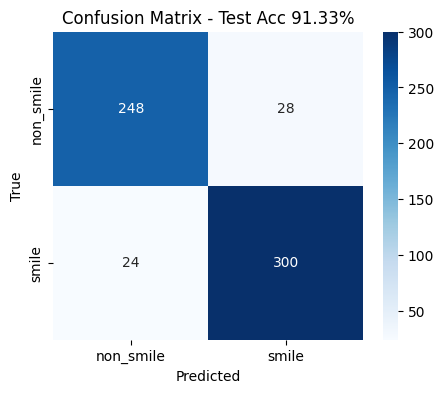


Classification Report:

              precision    recall  f1-score   support

   non_smile       0.91      0.90      0.91       276
       smile       0.91      0.93      0.92       324

    accuracy                           0.91       600
   macro avg       0.91      0.91      0.91       600
weighted avg       0.91      0.91      0.91       600



In [13]:
# Load best
chk = torch.load("best_model.pth", map_location=device)
model.load_state_dict(chk["model_state"])
model.eval()

all_preds = []
all_labels = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        preds = out.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

acc = accuracy_score(all_labels, all_preds) * 100
print(f"Test Accuracy: {acc:.3f}%  ({sum(np.array(all_preds)==np.array(all_labels))}/{len(all_labels)})")

# Confusion matrix & classification report
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["non_smile","smile"], yticklabels=["non_smile","smile"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix - Test Acc {acc:.2f}%")
plt.show()

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=["non_smile", "smile"]))
